In [ ]:
# Lasso Regression

# Lasso Regression — Figure 4-19

## Что это такое

Lasso (Least Absolute Shrinkage and Selection Operator) — ещё одна регуляризованная версия линейной регрессии, как и Ridge. Разница — в том, какая "норма" весов штрафуется.

## Формула (Equation 4-10)

Оригинал:

```
J(θ) = MSE(θ) + 2α ∑ᵢ₌₁ⁿ |θᵢ|
```

**Полный перевод предложения (дословно, из книги):**

> "Обратите внимание, что ℓ1-норма умножается на 2α, тогда как ℓ2-норма в ridge-регрессии умножалась на α / m. Эти коэффициенты были выбраны так, чтобы оптимальное значение α не зависело от размера обучающей выборки: разные нормы требуют разных коэффициентов (подробнее см. Scikit-Learn issue #15657)."

| Часть формулы | Как читается | Что означает |
|---|---|---|
| `J(θ)` | "джей от тета" | Итоговая функция стоимости — то, что модель пытается минимизировать |
| `MSE(θ)` | "эм-эс-и от тета" | Обычная ошибка предсказания (среднеквадратичная ошибка) |
| `α` (альфа) | "альфа" | Сила регуляризации. Чем больше — тем сильнее давление на веса |
| `∑ᵢ₌₁ⁿ` | "сумма по и от 1 до эн" | Знак суммы: означает "сложи то, что справа, для каждого i, начиная с i=1 и заканчивая i=n" |
| `n` | "эн" | Общее количество весов (признаков) в модели — сколько раз повторять суммирование |
| `i` | "и" | Индекс — просто "номер" текущего веса, по которому идёт перебор (1-й, 2-й, ..., n-й) |
| `θᵢ` | "тета-и" | Вес модели с номером i (например θ₁, θ₂, θ₃...) |
| `\|θᵢ\|` | "модуль тета-и" | Абсолютное значение веса (убирает знак минус, если он был) |
| `∑ᵢ₌₁ⁿ \|θᵢ\|` | "сумма модулей тета-и, от 1 до эн" | Складываем модули **всех** весов модели, от первого до n-го — это и есть ℓ1-норма |
| `2α ∑...` | — | Итоговый штраф: сумма модулей весов, умноженная на 2α |

**Простыми словами:** `∑ᵢ₌₁ⁿ` — это просто цикл `for i in range(1, n+1)`, только записанный математическими символами: "пройдись по всем весам модели (их всего n штук) и сложи их модули". Модель наказывается не только за ошибку предсказания, но и за каждый ненулевой вес. Из-за формы штрафа (модуль, а не квадрат) Lasso может обнулять веса полностью — в этом его отличие от Ridge, который только уменьшает веса, но никогда не доводит их до нуля.

## Что показывает Figure 4-19 (Внизу есть блок с кодом и этими графиками)

Два графика, три значения α на каждом (`α=0` — без регуляризации, среднее и `α=1` — сильная регуляризация).

| График | Что за модель | Что видно |
|---|---|---|
| Левый | Обычная линейная регрессия (только x¹) | Все линии почти прямые — изгибаться нечем, признак всего один |
| Правый | Полиномиальная регрессия (x¹...x¹⁰, 10 признаков) | При слабой регуляризации (`α=0`) модель дико скачет, подстраиваясь под шум. При сильной (`α=1`) — почти плоская линия (все веса занулены) |

## Про фразу "looks roughly cubic" , ниже у меня также в кодовой части есть принт где можно это увидеть

Автор описывает пунктирную зелёную линию (`α=0.01`) на правом графике как "примерно кубическую". Речь не о том, что визуально видно кубическую параболу — речь о том, что **почти все веса из 10 обнулились**, осталось совсем немного ненулевых. Оставшиеся признаки дают гладкую кривую с одним плавным изгибом — по сложности формы она напоминает низкую степень полинома (условно ≈3), а не дикую кривую 10-й степени.

На практике точный набор "выживших" степеней зависит от версии scikit-learn и случайных чисел — не стоит воспринимать "cubic" буквально как "выжили именно x¹, x², x³".

## Trade-off (компромисс)

- Слишком маленькая `α` → модель почти не регуляризована, переобучается, скачет по шуму.
- Слишком большая `α` → модель становится очень разреженной (sparse), почти все веса = 0, но точность предсказаний резко падает (модель предсказывает почти константу).

## Вывод

Lasso автоматически выполняет **feature selection** (отбор признаков) — сам решает, какие входные данные реально нужны, а какие можно выкинуть, обнулив их вес.

In [ ]:
from sklearn.linear_model import LinearRegression

def plot_model(model_class, polynomial, alphas, on_fit=None, **model_kwargs):
	plt.plot(X, y, "b.", linewidth=3)
	for alpha, style in zip(alphas, ("b:", "g--", "r-")):
		if alpha > 0:
			model = model_class(alpha, **model_kwargs)
		else:
			model = LinearRegression()

		poly = None
		if polynomial:
			poly = PolynomialFeatures(degree=10, include_bias=False)
			model = make_pipeline(poly, StandardScaler(), model)

		model.fit(X, y)
		y_new_regul = model.predict(X_new)
		plt.plot(X_new, y_new_regul, style, linewidth=2,
				 label=fr"$\alpha = {alpha}$")

		if on_fit is not None:
			on_fit(model, poly, alpha)

	plt.legend(loc="upper left")
	plt.xlabel("$x_1$")
	plt.axis([0, 3, 0, 3.5])
	plt.grid()

alpha=0.01:
  x: 0.1324
  x^2: -0.0000
  x^3: -0.0000
  x^4: -0.0000
  x^5: 0.0000
  x^6: 0.0000
  x^7: 0.0000
  x^8: 0.0000
  x^9: 0.0000
  x^10: 0.2913
alpha=1:
  x: 0.0000
  x^2: 0.0000
  x^3: 0.0000
  x^4: 0.0000
  x^5: 0.0000
  x^6: 0.0000
  x^7: 0.0000
  x^8: 0.0000
  x^9: 0.0000
  x^10: 0.0000


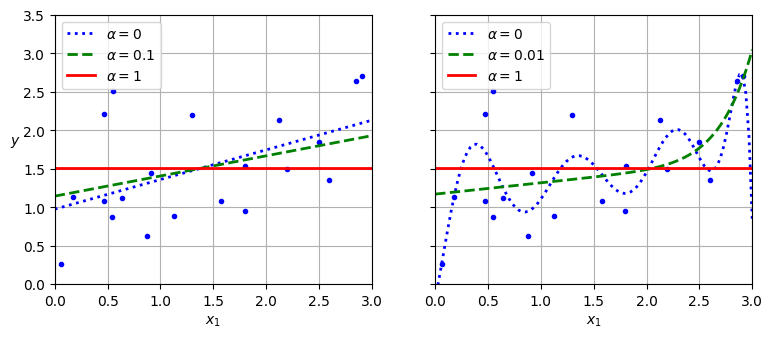

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5

X_new = np.linspace(0, 3, 100).reshape(100, 1)

def print_survivors(model, poly, alpha):
	if poly is None or alpha == 0:
		return
	last_step = model.steps[-1][1]
	feature_names = poly.get_feature_names_out(["x"])
	print(f"alpha={alpha}:")
	for name, c in zip(feature_names, last_step.coef_):
		print(f"  {name}: {c:.4f}")

plt.figure(figsize=(9, 3.5))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), on_fit=print_survivors, random_state=42)
plt.ylabel("$y$  ", rotation=0)
plt.subplot(122)
# PolynomialFeatures(degree=10) берет x и создает 10 новых столбцов x¹, x², x³, ..., x¹⁰
# Lasso каждому весу выставляет "штраф" за использование.
# Если вес даёт пользы меньше, чем стоит штраф — Lasso его обнуляет. Полностью, в ноль.
# В этом случае остались ток  'x', 'x^10' после Lasso
plot_model(Lasso, polynomial=True, alphas=(0, 1e-2, 1), on_fit=print_survivors, random_state=42)
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

# Lasso vs Ridge — разбор картинки (Figure 4-20)

Отвечает на вопрос: **почему именно Lasso (ℓ1) обнуляет веса, а Ridge (ℓ2) — только уменьшает их?** Ответ — в форме штрафа, если посмотреть на неё как на "ландшафт" (контурный график).

На картинке 4 панели: оси — это два веса модели, `θ1` и `θ2`. Цвет фона — величина штрафа/стоимости в этой точке (чем темнее — тем меньше).

| Панель | Что показывает |
|---|---|
| Верх-слева (`ℓ1 penalty`) | Форма штрафа `\|θ1\| + \|θ2\|` — ромб. Штраф падает **линейно и равномерно** по мере приближения к любой оси |
| Верх-справа (`Lasso`) | То же самое + добавлена ошибка (MSE). Белая линия — путь градиентного спуска |
| Низ-слева (`ℓ2 penalty`) | Форма штрафа `θ1² + θ2²` — круг. Штраф падает мягко, ускоряясь у краёв и замедляясь у центра |
| Низ-справа (`Ridge`) | То же самое + MSE. Путь градиентного спуска — почти прямая линия к центру |

![lasso](./lasso.png)

## Почему форма ромба (ℓ1) обнуляет веса

Если начать спуск, например, из точки `θ1=2, θ2=0.5`:

1. Оба веса уменьшаются **одинаковыми шагами** (штраф `|θ|` даёт постоянный "наклон" ±1, независимо от того, насколько вес близок к нулю).
2. Тот вес, что был ближе к нулю (`θ2=0.5`), долетает до нуля **первым**.
3. После этого путь "едет по желобу" вдоль оси `θ1=0` и там немного "трясётся" — потому что градиент `ℓ1` не сглаживается около нуля (это либо −1, либо +1, никогда не 0).
4. Итог: `θ2` реально становится равным нулю — вес обнулён полностью.

## Почему форма круга (ℓ2) не обнуляет веса

Штраф `θ²` **уменьшается сам собой** по мере приближения к нулю (производная от `θ²` — это `2θ`, а чем меньше `θ`, тем меньше и "сила притяжения" к нулю). Поэтому:

- Спуск идёт по прямой к центру, без "желобов".
- Ближе к оптимуму градиенты становятся мельче — спуск естественно замедляется, меньше "трясётся".
- Вес приближается к нулю, но никогда не достигает его точно.

## Что происходит при изменении α

- Увеличиваешь `α` → оптимальная точка (красный квадрат) сдвигается **ближе к нулю** (у Lasso может доехать точно до нуля, у Ridge — только приближается).
- Уменьшаешь `α` → точка сдвигается **дальше от нуля**, ближе к нерегуляризованному оптимуму (в примере из книги это `θ1=2, θ2=0.5`).

---

## Equation 4-11 — субградиент Lasso

Проблема: функция `|θ|` не дифференцируема в точке `θ=0` (там у неё "излом", обычной производной не существует). Поэтому вместо обычного градиента используется **субградиент** — специальная формула-заглушка для этой точки.

```
g(θ, J) = ∇θ MSE(θ) + 2α * [sign(θ1), sign(θ2), ..., sign(θn)]

sign(θᵢ) = -1, если θᵢ < 0
sign(θᵢ) =  0, если θᵢ = 0
sign(θᵢ) = +1, если θᵢ > 0
```

| Часть формулы | Как читается | Что означает |
|---|---|---|
| `g(θ, J)` | "жи от тета и джей" | Субградиент — направление шага для градиентного спуска |
| `∇θ MSE(θ)` | "набла тета от эм-эс-и" | Обычный градиент ошибки предсказания (насколько и куда двигать веса, чтобы уменьшить ошибку) |
| `sign(θᵢ)` | "сайн (знак) от тета-и" | Функция знака: возвращает −1, 0 или +1 в зависимости от знака веса |
| `2α * [sign(...)]` | — | Добавка от регуляризации: тянет каждый вес к нулю с одинаковой силой, независимо от его величины |

**Простыми словами:** обычный градиент говорит "куда двигаться, чтобы точнее предсказывать", а вторая часть формулы говорит "а ещё всегда подталкивай к нулю с одинаковой силой". Из-за этой "одинаковой силы" (а не пропорциональной величине веса, как в Ridge) Lasso и способен дожать вес ровно до нуля.

> **Совет из книги:** чтобы спуск не "трясся" бесконечно рядом с оптимумом, нужно постепенно уменьшать learning rate во время обучения.

## Пример кода

```python
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])
# array([1.87550211])
```

Альтернатива — тот же эффект, но через универсальный `SGDRegressor`:

```python
SGDRegressor(penalty="l1", alpha=0.1)
```